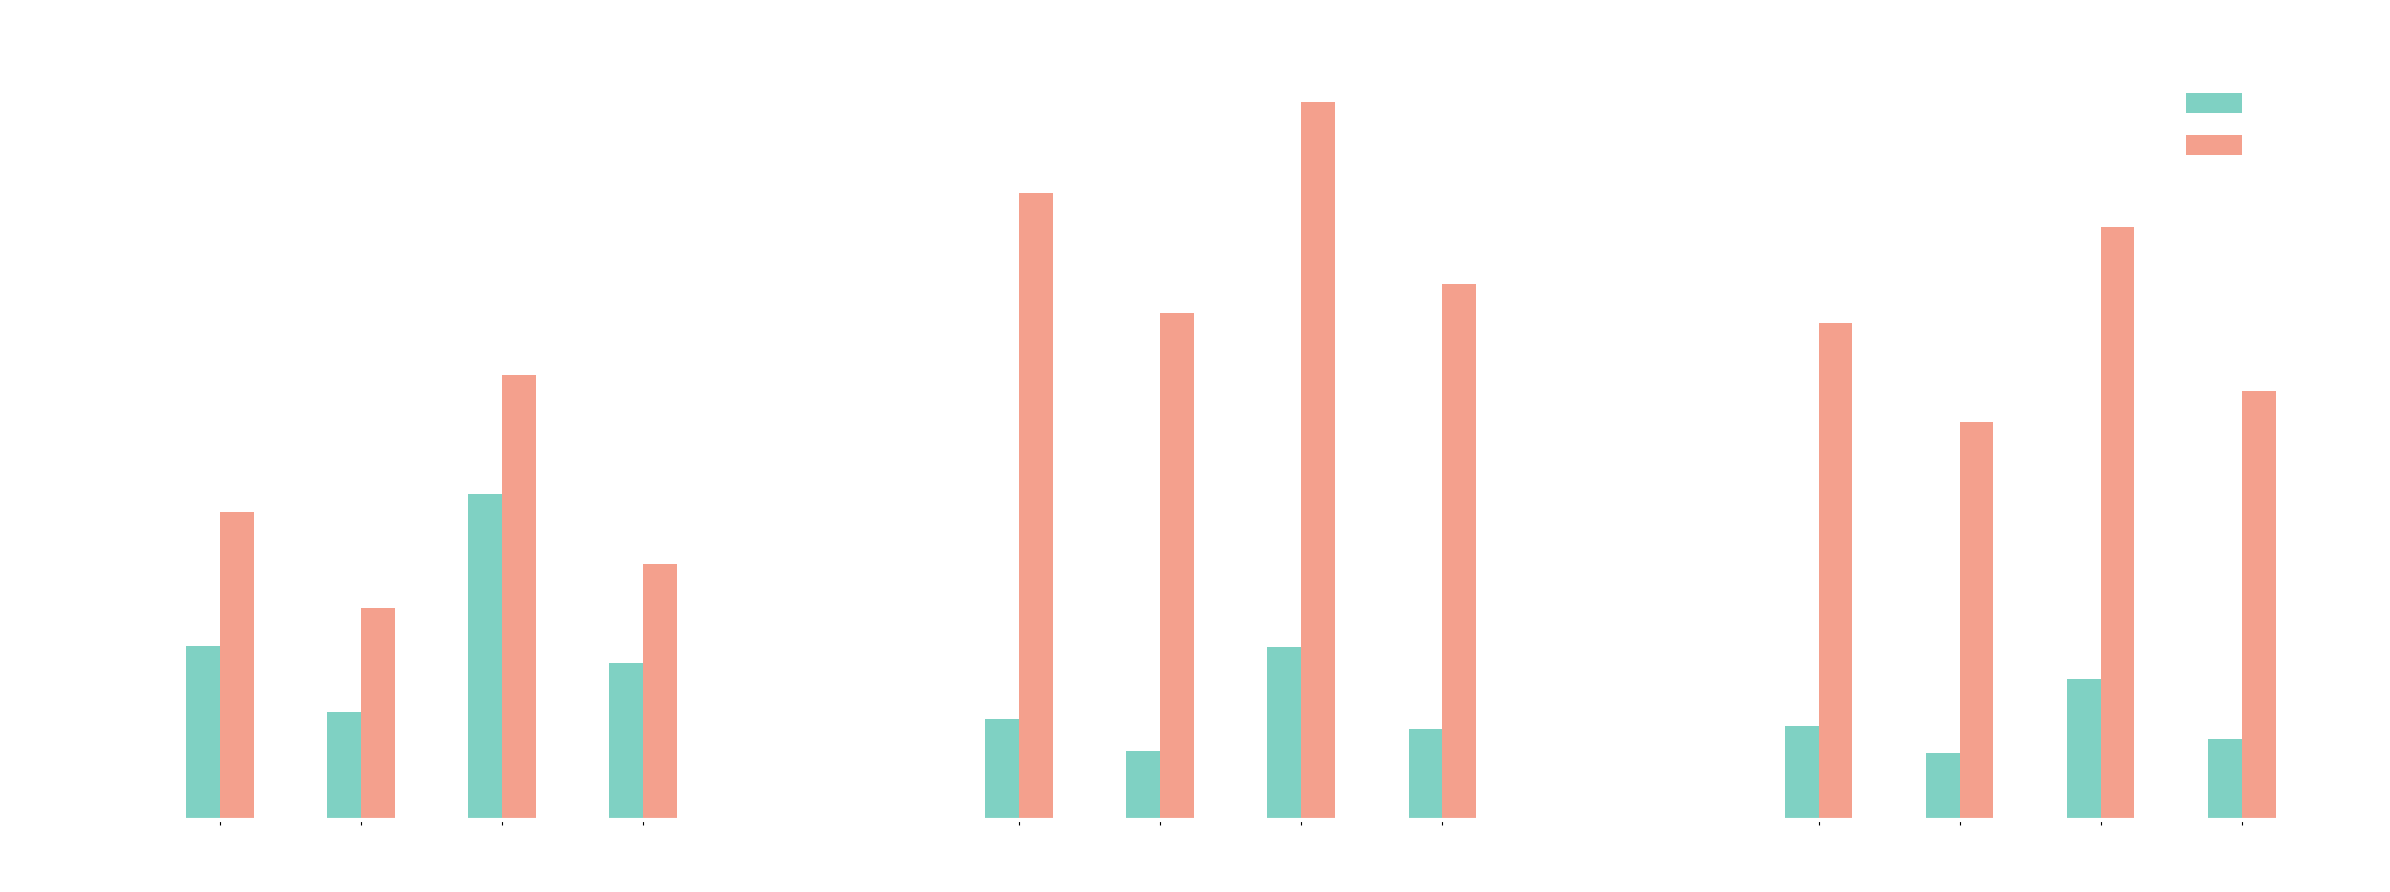

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = {
    "Dataset": [
        "Video Games", "Video Games",
        "Office Products", "Office Products",
        "Industrial & Scientific", "Industrial & Scientific"
    ],
    "Method": [
        "SASRec (Ours)", "Paper",
        "SASRec (Ours)", "Paper",
        "Industrial & Scientific", "Paper"
    ],
    "HR@5": [0.0284, 0.0501, 0.0164, 0.1019, 0.0153, 0.0807],
    "NDCG@5": [0.0176, 0.0345, 0.0113, 0.0824, 0.0109, 0.0647],
    "HR@10": [0.0530, 0.0723, 0.0282, 0.1167, 0.0229, 0.0964],
    "NDCG@10": [0.0256, 0.0416, 0.0149, 0.0871, 0.0132, 0.0697]
}

# Fix method typo for Industrial row
data["Method"] = [
    "SASRec (Ours)", "Paper",
    "SASRec (Ours)", "Paper",
    "SASRec (Ours)", "Paper"
]

df = pd.DataFrame(data)

metrics = ["HR@5", "NDCG@5", "HR@10", "NDCG@10"]
metric_labels = ["HR\n@5", "NDCG\n@5", "HR\n@10", "NDCG\n@10"]

datasets = [
    "Video Games",
    "Office Products",
    "Industrial & Scientific"
]

fig, ax = plt.subplots(figsize=(24, 9))

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

ours_color = "#7FD1C3"
paper_color = "#F4A08D"

bar_width = 0.18
metric_gap = 0.75
dataset_gap = 1.25

positions = []
labels = []
dataset_centers = []

current_pos = 0

for dataset in datasets:
    start = current_pos

    for metric, metric_label in zip(metrics, metric_labels):
        ours = df[
            (df["Dataset"] == dataset) &
            (df["Method"] == "SASRec (Ours)")
        ][metric].values[0]

        paper = df[
            (df["Dataset"] == dataset) &
            (df["Method"] == "Paper")
        ][metric].values[0]

        ax.bar(
            current_pos - bar_width / 2,
            ours,
            width=bar_width,
            color=ours_color,
            label="Ours" if (dataset == datasets[0] and metric == metrics[0]) else ""
        )

        ax.bar(
            current_pos + bar_width / 2,
            paper,
            width=bar_width,
            color=paper_color,
            label="Paper" if (dataset == datasets[0] and metric == metrics[0]) else ""
        )

        positions.append(current_pos)
        labels.append(metric_label)

        current_pos += metric_gap

    end = current_pos - metric_gap
    dataset_centers.append((start + end) / 2)

    current_pos += dataset_gap

for center, dataset in zip(dataset_centers, datasets):
    ax.text(
        center,
        ax.get_ylim()[1] * 1.04,
        dataset,
        ha="center",
        fontsize=24,
        fontweight="bold",
        color="white"
    )

ax.set_xticks(positions)
ax.set_xticklabels(
    labels,
    fontsize=18,
    fontweight="bold",
    color="white"
)

ax.set_ylabel("")

ax.tick_params(axis="y", colors="white", labelsize=18)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

legend = ax.legend(
    fontsize=20,
    frameon=False,
    labelcolor="white",
    loc="upper right"
)

for text in legend.get_texts():
    text.set_fontweight("bold")

plt.tight_layout()
plt.show()

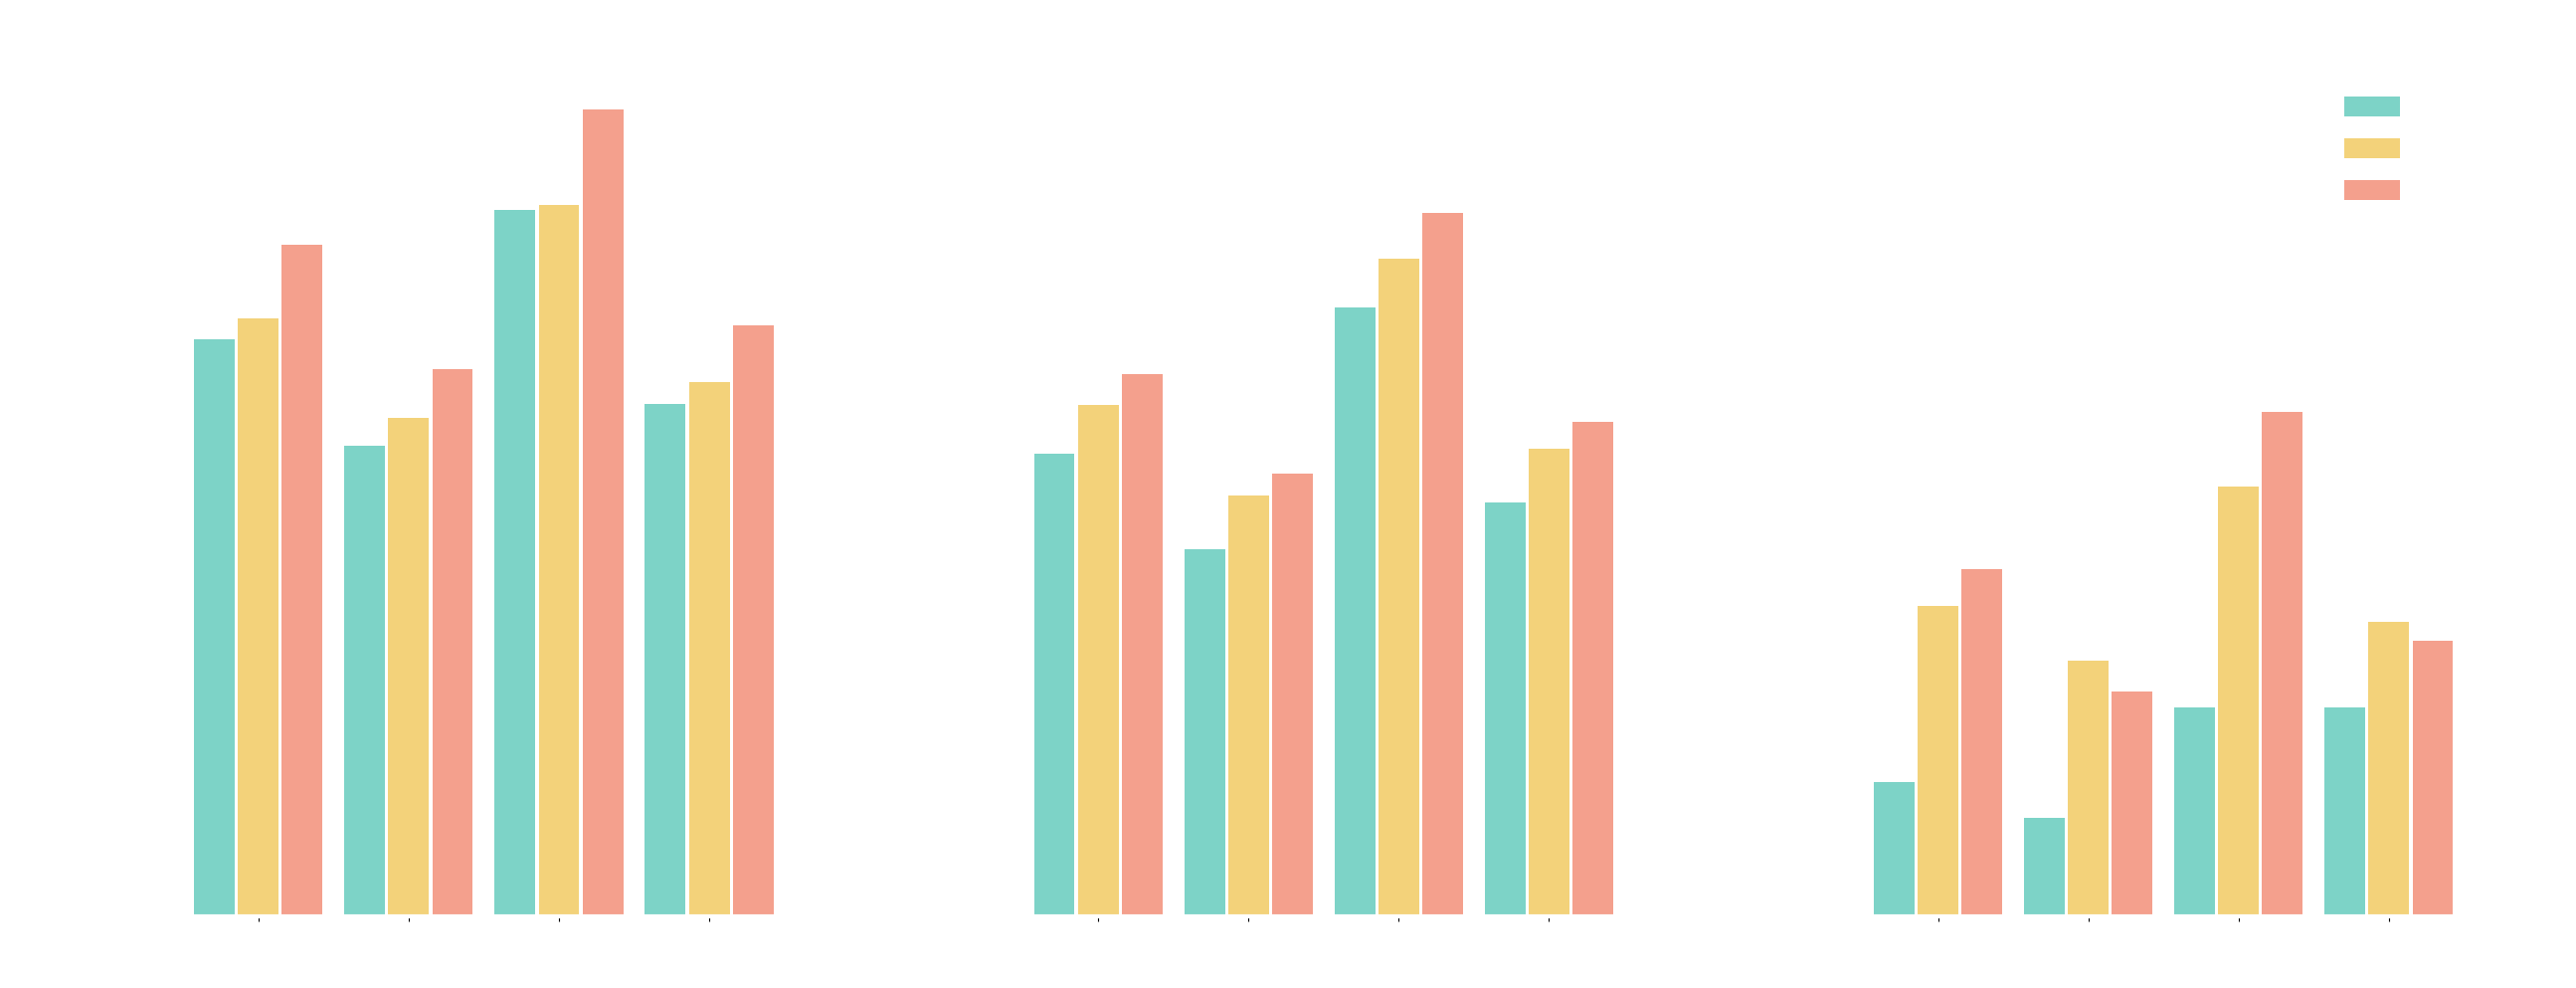

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = {
    "Dataset": [
        "Office Products", "Office Products", "Office Products",
        "Industrial & Scientific", "Industrial & Scientific", "Industrial & Scientific",
        "Video Games", "Video Games", "Video Games"
    ],
    "Method": [
        "Stage 2", "Stage 3", "Paper",
        "Stage 2", "Stage 3", "Paper",
        "Stage 2", "Stage 3", "Paper"
    ],
    "HR@5": [0.1180, 0.1223, 0.1373, 0.0946, 0.1046, 0.1109, 0.0275, 0.0635, 0.0710],
    "NDCG@5": [0.0963, 0.1019, 0.1119, 0.0750, 0.0860, 0.0905, 0.0202, 0.0524, 0.0460],
    "HR@10": [0.1443, 0.1453, 0.1648, 0.1244, 0.1343, 0.1438, 0.0428, 0.0879, 0.1031],
    "NDCG@10": [0.1048, 0.1093, 0.1208, 0.0846, 0.0956, 0.1010, 0.0428, 0.0602, 0.0563]
}

df = pd.DataFrame(data)

metrics = ["HR@5", "NDCG@5", "HR@10", "NDCG@10"]
metric_labels = ["HR\n@5", "NDCG\n@5", "HR\n@10", "NDCG\n@10"]

datasets = [
    "Office Products",
    "Industrial & Scientific",
    "Video Games"
]

fig, ax = plt.subplots(figsize=(26, 10))

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

stage2_color = "#7DD3C7"
stage3_color = "#F3D27A"
paper_color = "#F4A08D"

bar_width = 0.23
metric_gap = 0.85
dataset_gap = 1.35

# Tiny gap between bars
gap_factor = 1.08

positions = []
labels = []
dataset_centers = []

current_pos = 0

for dataset in datasets:

    start = current_pos

    for metric, metric_label in zip(metrics, metric_labels):

        stage2 = df[
            (df["Dataset"] == dataset) &
            (df["Method"] == "Stage 2")
        ][metric].values[0]

        stage3 = df[
            (df["Dataset"] == dataset) &
            (df["Method"] == "Stage 3")
        ][metric].values[0]

        paper = df[
            (df["Dataset"] == dataset) &
            (df["Method"] == "Paper")
        ][metric].values[0]

        offsets = [
            -bar_width * gap_factor,
            0,
            bar_width * gap_factor
        ]

        ax.bar(
            current_pos + offsets[0],
            stage2,
            width=bar_width,
            color=stage2_color,
            label="Stage 2"
            if (dataset == datasets[0] and metric == metrics[0]) else ""
        )

        ax.bar(
            current_pos + offsets[1],
            stage3,
            width=bar_width,
            color=stage3_color,
            label="Stage 3"
            if (dataset == datasets[0] and metric == metrics[0]) else ""
        )

        ax.bar(
            current_pos + offsets[2],
            paper,
            width=bar_width,
            color=paper_color,
            label="Paper"
            if (dataset == datasets[0] and metric == metrics[0]) else ""
        )

        positions.append(current_pos)
        labels.append(metric_label)

        current_pos += metric_gap

    end = current_pos - metric_gap
    dataset_centers.append((start + end) / 2)

    current_pos += dataset_gap

for center, dataset in zip(dataset_centers, datasets):
    ax.text(
        center,
        ax.get_ylim()[1] * 1.04,
        dataset,
        ha="center",
        fontsize=24,
        fontweight="bold",
        color="white"
    )

ax.set_xticks(positions)
ax.set_xticklabels(
    labels,
    fontsize=18,
    fontweight="bold",
    color="white"
)

ax.set_ylabel("")

ax.tick_params(
    axis="y",
    colors="white",
    labelsize=18
)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

legend = ax.legend(
    fontsize=20,
    frameon=False,
    labelcolor="white",
    loc="upper right"
)

for text in legend.get_texts():
    text.set_fontweight("bold")

plt.tight_layout()
plt.show()

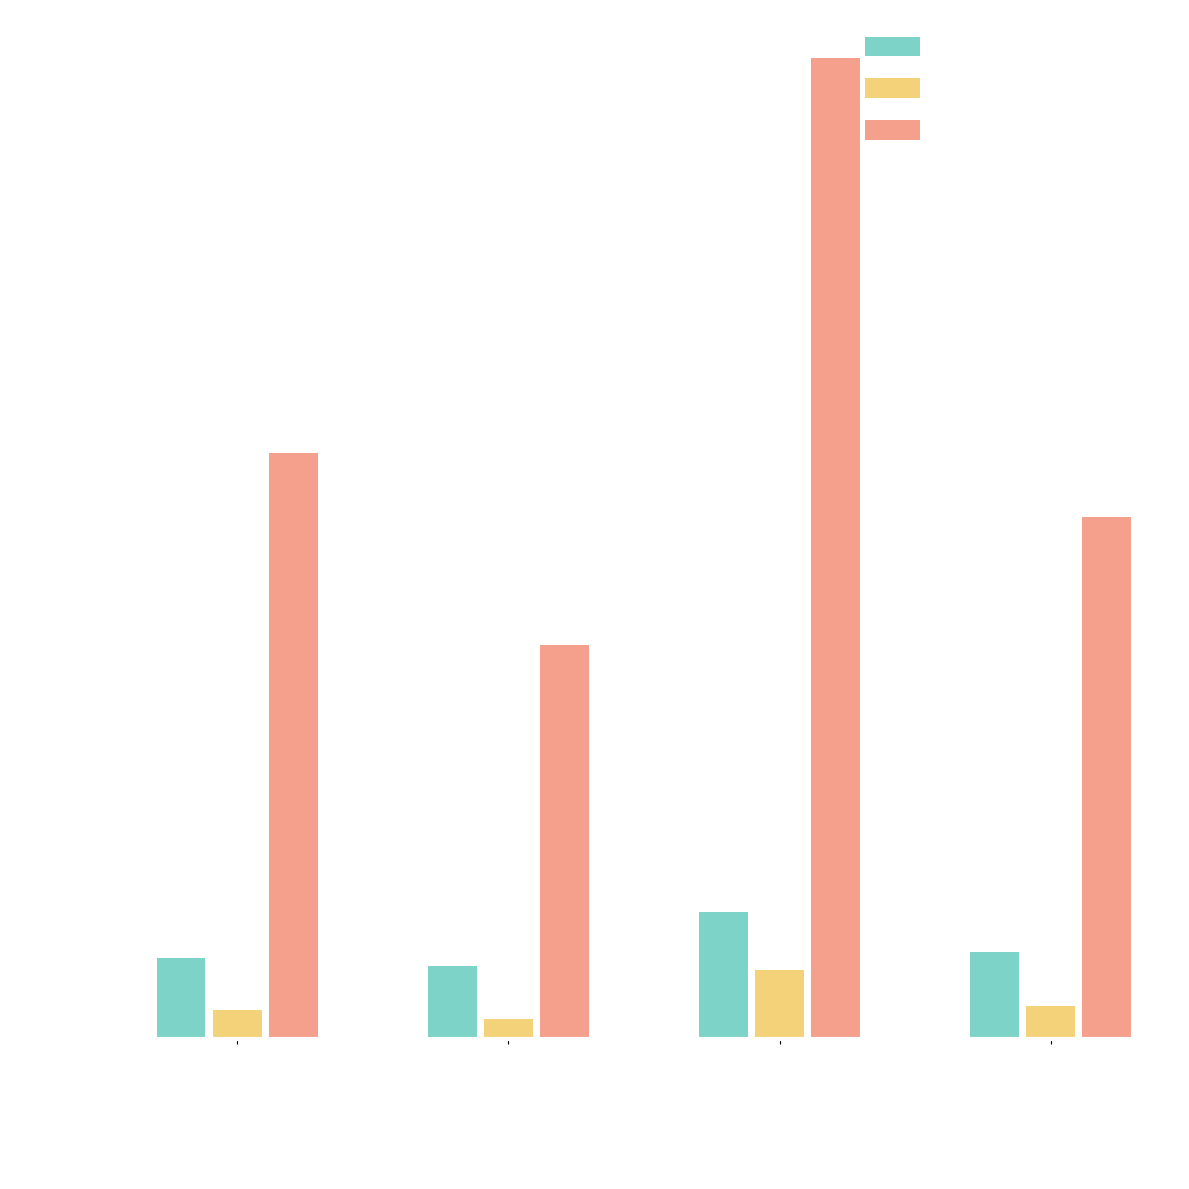

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = {
    "Method": ["Stage 2 (SFT)", "Stage 3 (RL)", "SASRec"],
    "HR@5": [0.0014, 0.0005, 0.0101],
    "NDCG@5": [0.00126, 0.00035, 0.0068],
    "HR@10": [0.0022, 0.0012, 0.0169],
    "NDCG@10": [0.00151, 0.00057, 0.0090]
}

df = pd.DataFrame(data)

metrics = ["HR@5", "NDCG@5", "HR@10", "NDCG@10"]

fig, ax = plt.subplots(figsize=(12, 12))

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

x_positions = np.arange(len(metrics))

width = 0.18
gap = 1.15

stage2_values = df[df["Method"] == "Stage 2 (SFT)"][metrics].values.flatten()
stage3_values = df[df["Method"] == "Stage 3 (RL)"][metrics].values.flatten()
sasrec_values = df[df["Method"] == "SASRec"][metrics].values.flatten()

stage2_color = "#7DD3C7"
stage3_color = "#F3D27A"
sasrec_color = "#F4A08D"  # purple

ax.bar(
    x_positions - width * gap,
    stage2_values,
    width,
    label="Stage 2 (SFT)",
    color=stage2_color
)

ax.bar(
    x_positions,
    stage3_values,
    width,
    label="Stage 3 (RL)",
    color=stage3_color
)

ax.bar(
    x_positions + width * gap,
    sasrec_values,
    width,
    label="SASRec",
    color=sasrec_color
)

ax.set_xticks(x_positions)
ax.set_xticklabels(
    metrics,
    rotation=45,
    ha="right",
    fontsize=20,
    fontweight="bold",
    color="white"
)

ax.tick_params(
    axis="y",
    labelsize=20,
    colors="white"
)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

legend = ax.legend(
    fontsize=20,
    frameon=False,
    labelcolor="white",
    loc="upper right"
)

for text in legend.get_texts():
    text.set_fontweight("bold")

plt.tight_layout()
plt.show()

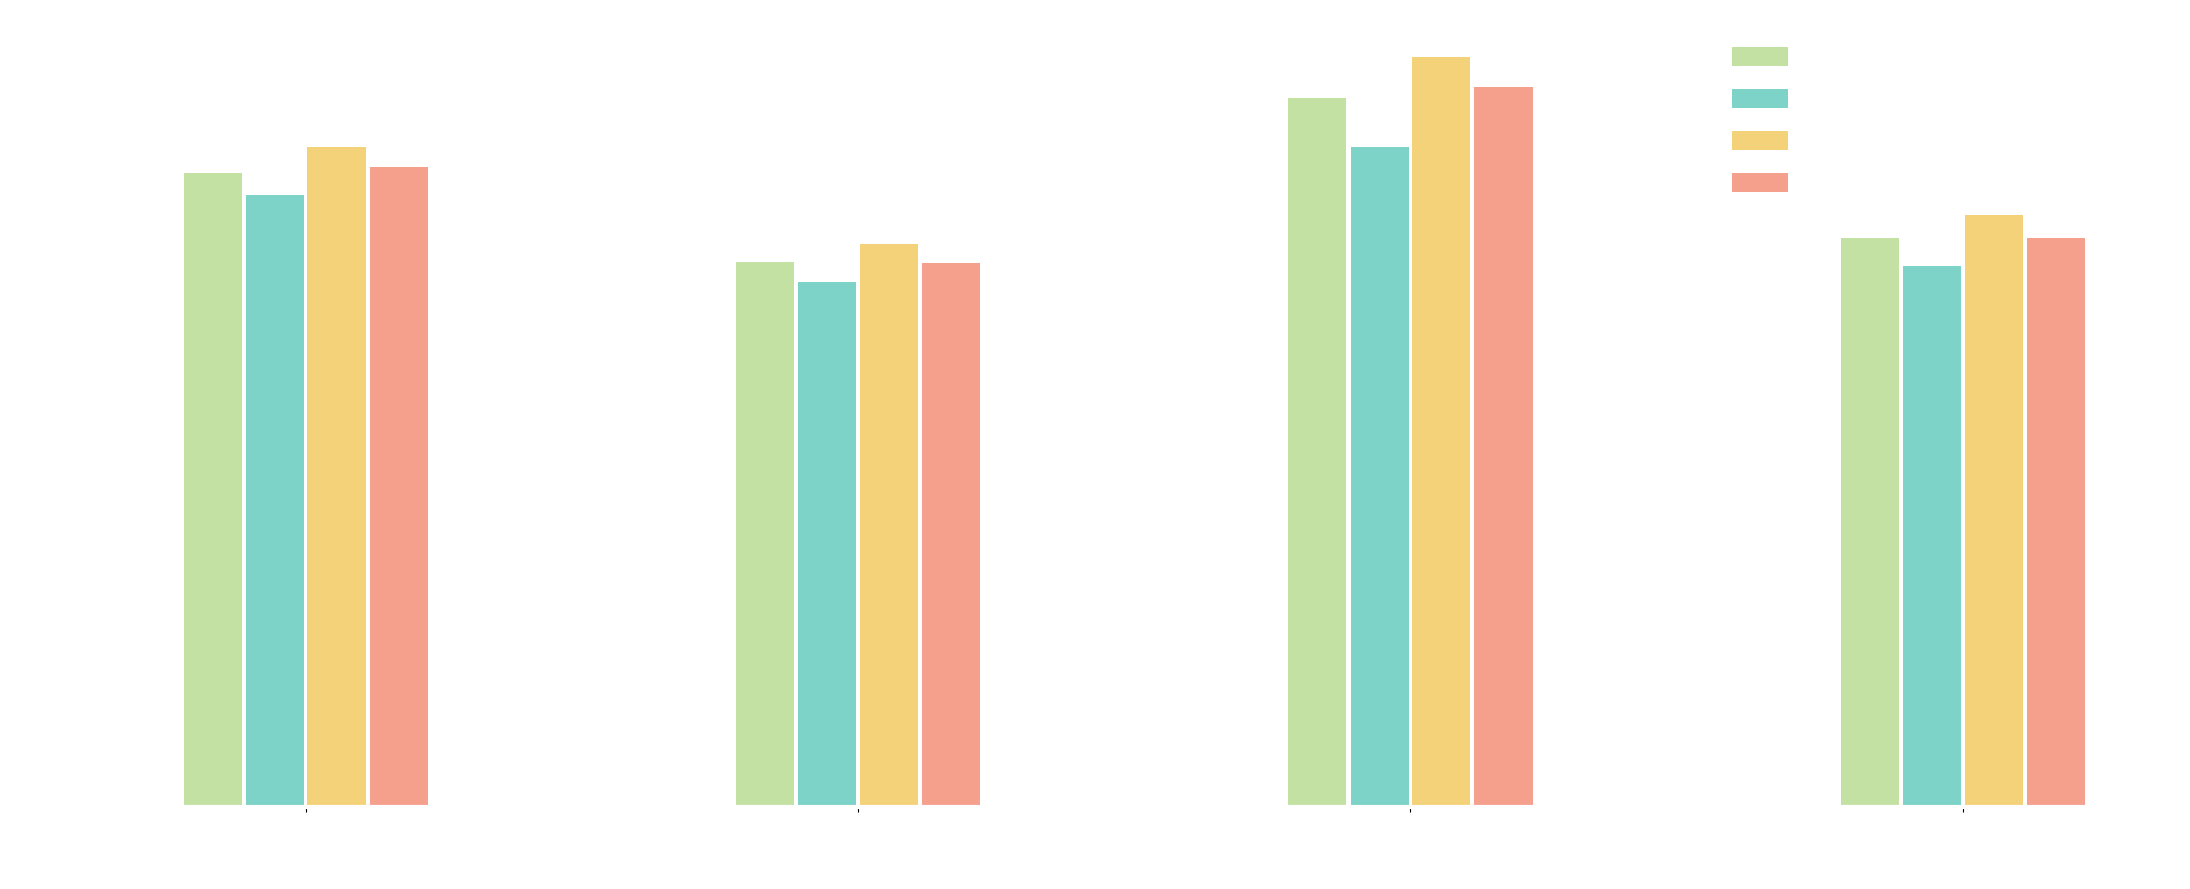

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = {
    "Stage": [
        "Stage 3 No Reasoning", "Stage 3 No Reasoning", "Stage 3 No Reasoning", "Stage 3 No Reasoning",
        "LoRA No Reasoning", "LoRA No Reasoning", "LoRA No Reasoning", "LoRA No Reasoning",
        "Stage 3 Reasoning", "Stage 3 Reasoning", "Stage 3 Reasoning", "Stage 3 Reasoning",
        "LoRA Reasoning", "LoRA Reasoning", "LoRA Reasoning", "LoRA Reasoning"
    ],
    "Metric": [
        "HR@5", "NDCG@5", "HR@10", "NDCG@10",
        "HR@5", "NDCG@5", "HR@10", "NDCG@10",
        "HR@5", "NDCG@5", "HR@10", "NDCG@10",
        "HR@5", "NDCG@5", "HR@10", "NDCG@10"
    ],
    "Score": [
        0.1289, 0.1107, 0.1441, 0.1156,
        0.1342, 0.1144, 0.1525, 0.1204,
        0.1245, 0.1067, 0.1342, 0.1099,
        0.1301, 0.1105, 0.1463, 0.1157
    ]
}

df = pd.DataFrame(data)

metrics = ["HR@5", "NDCG@5", "HR@10", "NDCG@10"]
metric_labels = ["HR\n@5", "NDCG\n@5", "HR\n@10", "NDCG\n@10"]

fig, ax = plt.subplots(figsize=(22, 9))

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

stage3_direct_color = "#C4E1A4"
lora_direct_color = "#F3D27A"
stage3_generated_color = "#7DD3C7"
lora_generated_color = "#F4A08D"

bar_width = 0.1
metric_gap = 0.95

x_positions = np.arange(len(metrics)) * metric_gap

methods = [
    "Stage 3 No Reasoning",
    "LoRA No Reasoning",
    "Stage 3 Reasoning",
    "LoRA Reasoning"
]

methods = [
    "Stage 3 No Reasoning",
    "Stage 3 Reasoning",
    "LoRA No Reasoning",
    "LoRA Reasoning"
]

colors = [
    stage3_direct_color,
    stage3_generated_color,
    lora_direct_color,
    lora_generated_color
]

# Tiny gap between bars
offsets = [
    -1.6 * bar_width,
    -0.53 * bar_width,
     0.53 * bar_width,
     1.6 * bar_width
]

for method, color, offset in zip(methods, colors, offsets):
    values = [
        df[
            (df["Stage"] == method) &
            (df["Metric"] == metric)
        ]["Score"].values[0]
        for metric in metrics
    ]

    ax.bar(
        x_positions + offset,
        values,
        width=bar_width,
        label=method,
        color=color
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(
    metric_labels,
    fontsize=22,
    fontweight="bold",
    color="white"
)

ax.set_ylabel("")

ax.tick_params(
    axis="y",
    labelsize=20,
    colors="white"
)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")

ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

legend = ax.legend(
    fontsize=20,
    frameon=False,
    labelcolor="white",
    loc="upper right"
)

for text in legend.get_texts():
    text.set_fontweight("bold")

plt.tight_layout()
plt.show()